# Physics Informed Log-Evidence

## Problem

Our goal is to solve Poisson equation on $[-1, 1]^2$, 
$$
\begin{align*}
    \begin{cases}
    \Delta u(z) = f(z) & \qquad z \in (-1, 1)^2 \\ 
    u(z) = 0 & \qquad z \in \partial [-1, 1]^2
    \end{cases}
\end{align*}
$$
with the forcing function $f(x, y) = 10 (1 + \sin(2 \pi x) + \sin(2 \pi y))$. The solution is plotted below. 

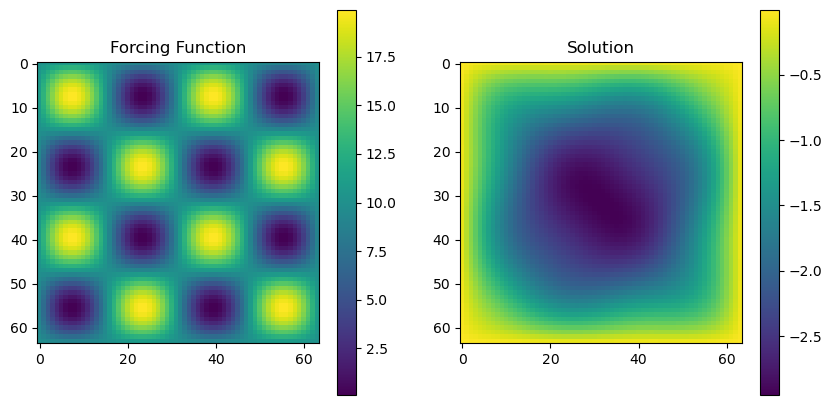

In [38]:
import matplotlib.pyplot as plt 
from models import Poisson2D 

P = Poisson2D()

plt.subplot(1, 2, 1)
plt.title('Forcing Function')
plt.imshow(P.forcing.data)
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title('Solution')
plt.imshow(P._sol.data)
plt.colorbar()

plt.gcf().set_size_inches(10, 5)
plt.show()

In [3]:
import os 
import pickle 
import numpy as np

expts_to_load = [
    "MLP-lg-cl",
    "MLP-md-cl",
    "MLP-sm-cl",
    "RBF-md-cl",
    "RBF-lg-cl"
]

def load_expts(e):
    run_dirs = [x for x in os.listdir(f"expts/{e}") if not ".yml" in x]
    runs = {}
    for r in run_dirs:
        with open(f"expts/{e}/{r}/diagnostics.pkl", "rb") as f_in:
            dict = pickle.load(f_in)
            params = ",".join(r.split("-")[1:])
            runs[params] = dict
    return runs
        
expt_data = {
    e: load_expts(e) for e in expts_to_load
}

In [3]:
mlp_sm = [(expt_data['MLP-sm-cl'][p]['pile'][-1]['pile'])
          for p in expt_data['MLP-sm-cl'].keys()]
mlp_md = [expt_data['MLP-md-cl'][p]['pile'][-1]['pile'] for p in expt_data['MLP-md-cl'].keys()]
mlp_lg = [expt_data['MLP-lg-cl'][p]['pile'][-1]['pile'] for p in expt_data['MLP-lg-cl'].keys()]

pile_scores = []
data_errs = []
phys_errs = []
for k in ['sm', 'md', 'lg']:
    params = expt_data[f'MLP-{k}-cl'].keys()
    last_iter = [expt_data[f'MLP-{k}-cl'][p]['pile'][-1] for p in params]
    piles = [itr['pile'] for itr in last_iter]
    pile_scores.append(piles)

    params = expt_data[f'MLP-{k}-cl'].keys()
    last_iter = [expt_data[f'MLP-{k}-cl'][p]['generalization'][-1] for p in params]
    gen_err = [itr['model_gen_error'] for itr in last_iter]
    phys_err = [itr['model_phys_error'] for itr in last_iter]
    data_errs.append(gen_err)
    phys_errs.append(phys_err)
    
    
rbf_pile_scores = [expt_data[f'RBF-lg-cl'][p]['pile'][-1]['pile'] for p in expt_data[f'RBF-lg-cl']]
rbf_data_errs = [expt_data[f'RBF-lg-cl'][p]['generalization'][-1]['model_gen_error'] for p in expt_data[f'RBF-lg-cl']]
rbf_phys_errs = [expt_data[f'RBF-lg-cl'][p]['generalization'][-1]['model_phys_error'] for p in expt_data[f'RBF-lg-cl']]

pile_scores.append(rbf_pile_scores)
data_errs.append(rbf_data_errs)
phys_errs.append(rbf_phys_errs)



In [4]:
pile_scores

[[Array(4254.8413, dtype=float32),
  Array(4356.568, dtype=float32),
  Array(4305.17, dtype=float32),
  Array(4392.139, dtype=float32),
  Array(4236.3794, dtype=float32)],
 [Array(4298.9844, dtype=float32),
  Array(4387.9463, dtype=float32),
  Array(4340.964, dtype=float32),
  Array(4437.7876, dtype=float32),
  Array(4253.0625, dtype=float32)],
 [Array(4348.6714, dtype=float32),
  Array(4476.9683, dtype=float32),
  Array(4415.9316, dtype=float32),
  Array(4526.774, dtype=float32),
  Array(4332.386, dtype=float32)],
 [Array(4123.533, dtype=float32),
  Array(4936.9927, dtype=float32),
  Array(4205.961, dtype=float32),
  Array(4492.9556, dtype=float32),
  Array(2748.0913, dtype=float32)]]

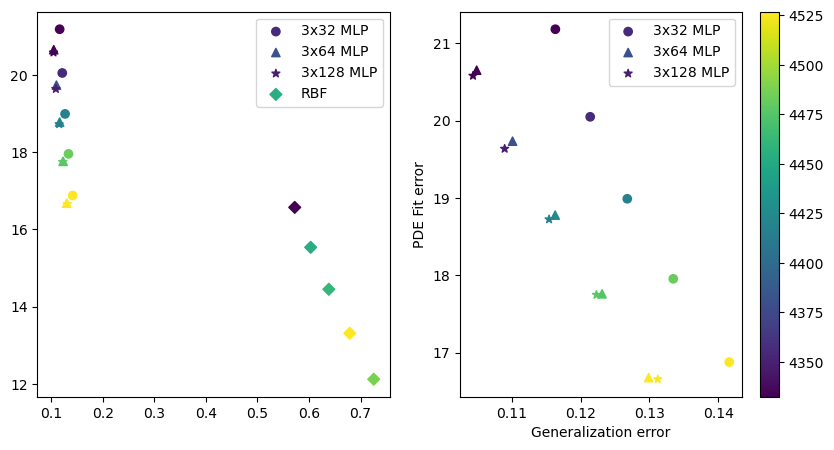

In [5]:
import matplotlib.pyplot as plt

min = np.min([x for y in pile_scores for x in y])
ptp = np.ptp([x for y in pile_scores for x in y])
normalize = lambda x: (np.array(x) - min)/ptp


plt.subplot(1, 2, 1)
plt.scatter(data_errs[0], phys_errs[0], c = pile_scores[0], label="3x32 MLP")
plt.scatter(data_errs[1], phys_errs[1], marker="^", c = pile_scores[1], label="3x64 MLP")
plt.scatter(data_errs[2], phys_errs[2], marker="*", c = pile_scores[2], label="3x128 MLP")
plt.scatter(data_errs[3], phys_errs[3], marker="D", c = pile_scores[3], label="RBF")
plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(data_errs[0], phys_errs[0], c = pile_scores[0], label="3x32 MLP")
plt.scatter(data_errs[1], phys_errs[1], marker="^", c = pile_scores[1], label="3x64 MLP")
plt.scatter(data_errs[2], phys_errs[2], marker="*", c = pile_scores[2], label="3x128 MLP")
plt.legend()
plt.colorbar()
plt.xlabel('Generalization error')
plt.ylabel('PDE Fit error')

plt.gcf().set_size_inches(10, 5)

plt.savefig('TEMP.png')

# Sanity Checks: Kernel Methods

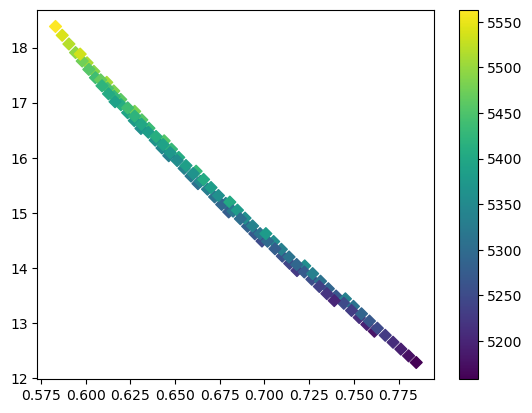

In [34]:
e = load_expts('RBF-lg-cl-noisetest')
e2 = load_expts('RBF-lg-cl-noisetest-3')

rbf_pile_scores = [e[p]['pile'][-1]['pile'] for p in e]
rbf_data_errs = [e[p]['generalization'][-1]['model_gen_error'] for p in e]
rbf_phys_errs = [e[p]['generalization'][-1]['model_phys_error'] for p in e]

plt.scatter(rbf_data_errs, rbf_phys_errs, marker="D", c = rbf_pile_scores)
plt.colorbar()


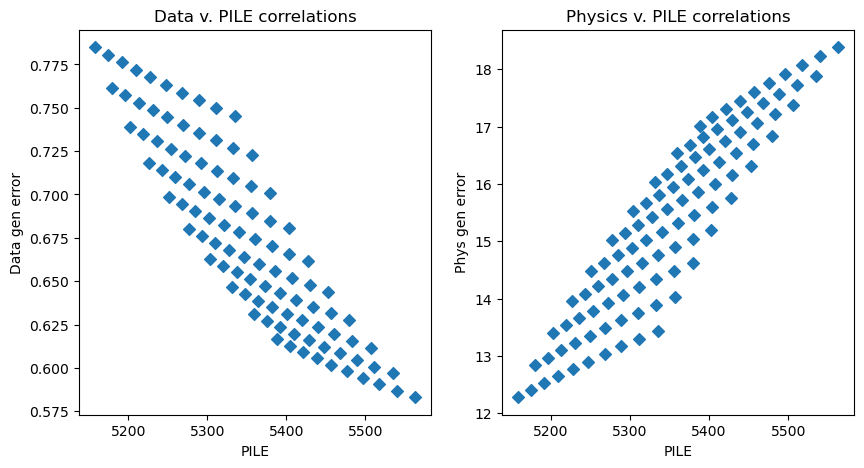

In [35]:
plt.subplot(1, 2, 1)
plt.title("Data v. PILE correlations")
plt.scatter(rbf_pile_scores, rbf_data_errs, marker="D")
plt.xlabel('PILE')
plt.ylabel('Data gen error')
plt.subplot(1, 2, 2)
plt.title("Physics v. PILE correlations")
plt.scatter(rbf_pile_scores, rbf_phys_errs, marker="D")
plt.xlabel('PILE')
plt.ylabel('Phys gen error')
plt.gcf().set_size_inches(10, 5)


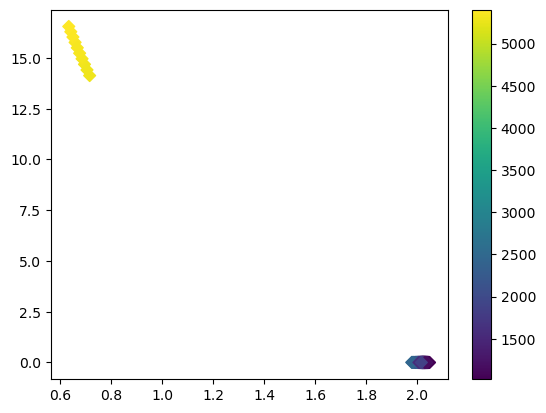

In [36]:
e = e2
rbf_pile_scores = [e[p]['pile'][-1]['pile'] for p in e]
rbf_data_errs = [e[p]['generalization'][-1]['model_gen_error'] for p in e]
rbf_phys_errs = [e[p]['generalization'][-1]['model_phys_error'] for p in e]

plt.scatter(rbf_data_errs, rbf_phys_errs, marker="D", c = rbf_pile_scores)
plt.colorbar()
plt.show()



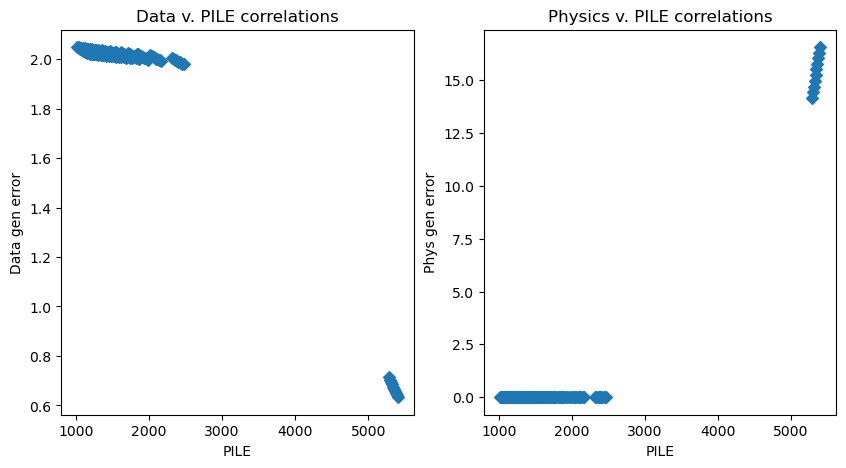

In [37]:

plt.subplot(1, 2, 1)
plt.title("Data v. PILE correlations")
plt.scatter(rbf_pile_scores, rbf_data_errs, marker="D")
plt.xlabel('PILE')
plt.ylabel('Data gen error')
plt.subplot(1, 2, 2)
plt.title("Physics v. PILE correlations")
plt.scatter(rbf_pile_scores, rbf_phys_errs, marker="D")
plt.xlabel('PILE')
plt.ylabel('Phys gen error')
plt.gcf().set_size_inches(10, 5)

